<a href="https://colab.research.google.com/github/viraaze/data_science/blob/main/analiza_v2_bankruptcy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo
!pip install catboost
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 5.4 MB/s eta 0:00:00


In [ ]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# MODELE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from feature_engine.selection import SmartCorrelatedSelection



# METRYKI
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    make_scorer,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    average_precision_score,
)

from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

In [ ]:

# fetch dataset
taiwanese_bankruptcy_prediction = fetch_ucirepo(id=572)

# metadata
print(taiwanese_bankruptcy_prediction.metadata)

# variable information
print(taiwanese_bankruptcy_prediction.variables)


{'uci_id': 572, 'name': 'Taiwanese Bankruptcy Prediction', 'repository_url': 'https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction', 'data_url': 'https://archive.ics.uci.edu/static/public/572/data.csv', 'abstract': 'The data were collected from the Taiwan Economic Journal  for the years 1999 to 2009. Company bankruptcy was defined based on the business regulations of the Taiwan Stock Exchange.', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 6819, 'num_features': 95, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Bankrupt?'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5004D', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': None, 'purpose': None, 'funded_by': None, 'instances_represent': None, 'recommended_data_splits': None, 'sensitive_data': Non

In [ ]:
X = taiwanese_bankruptcy_prediction.data.features
y = taiwanese_bankruptcy_prediction.data.targets.rename({"Bankrupt?": "Bankrupt"}, axis=1)

df = pd.concat([X, y], axis=1)

df

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474,1
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982,1
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,0.781588,...,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890,0
6815,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,0.781586,...,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284,0
6816,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,0.781546,...,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649,0
6817,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,0.781663,...,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009,0


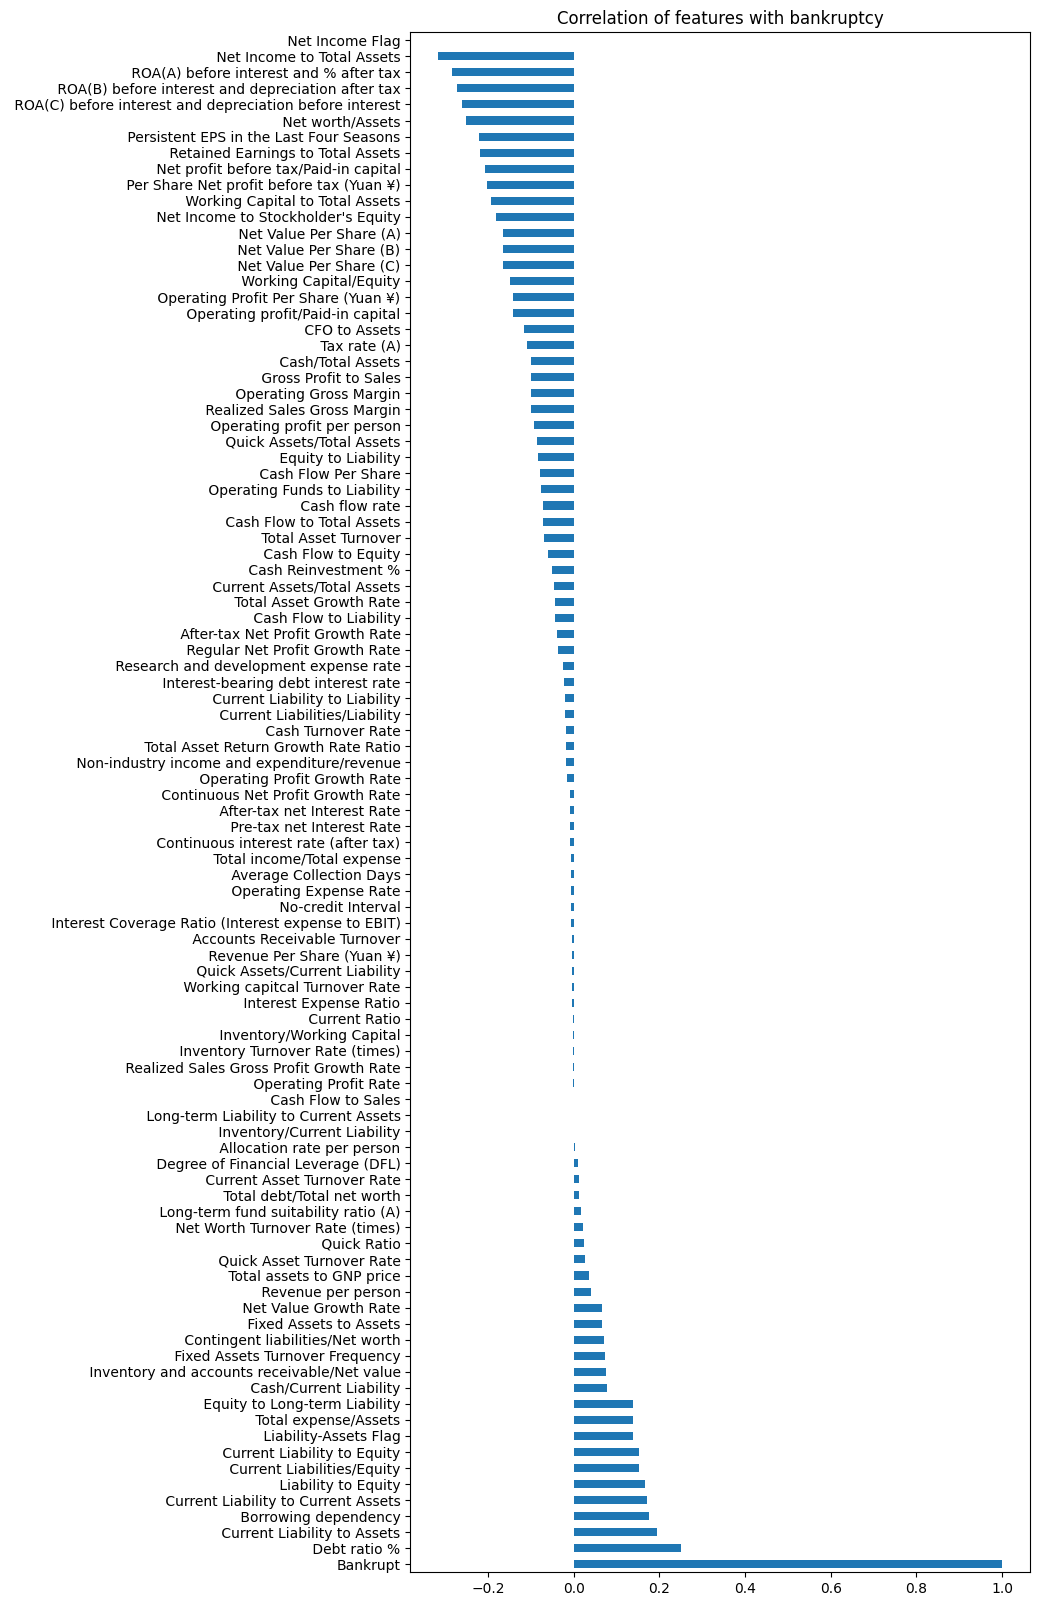

In [ ]:
corr_target = df.corr(numeric_only=True)['Bankrupt'].sort_values(ascending=False)

plt.figure(figsize=(8,20))
corr_target.plot(kind='barh')
plt.title("Correlation of features with bankruptcy")
plt.show()

<Axes: >

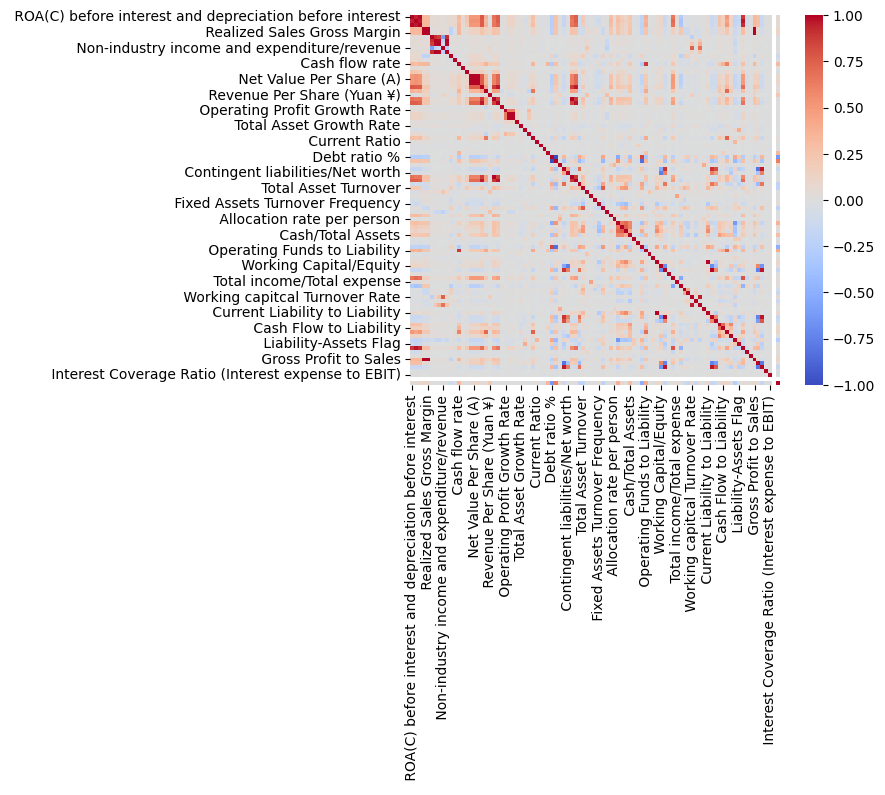

In [ ]:
corr = df.drop(columns=['Bankrupt']).corr()
sns.heatmap(corr, cmap="coolwarm", square=True)

array([[<Axes: title={'center': 'Bankrupt'}>]], dtype=object)

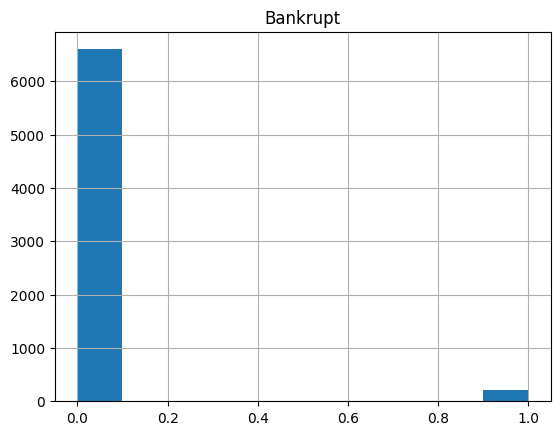

In [ ]:
y.hist()

In [ ]:
len(y[y['Bankrupt'] == 0]) / len(y), len(y[y['Bankrupt'] == 0]), len(y)
#

(0.967737204868749, 6599, 6819)

In [ ]:
X.shape

(6819, 95)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

In [ ]:

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


In [ ]:
param_grid = [
    # 1. Logistic Regression: Good for baseline and interpretability
    {
        "classifier": [LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')],
        'classifier__C': [0.01, 0.1, 1],
        'classifier__penalty': ['l1', 'l2']
    },
    # # 2. Random Forest: Robust to outliers and non-linearities
    {
        "classifier": [RandomForestClassifier(random_state=42, class_weight='balanced_subsample')],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10],
        'classifier__min_samples_leaf': [2, 4]
    },
    {
        # Balanced RF: Undersamples the majority class for EVERY tree
        "classifier": [BalancedRandomForestClassifier(random_state=42, sampling_strategy='auto')],
        'classifier__n_estimators': [200, 500],
        'classifier__max_depth': [10, 15],
    },
    {
        # EasyEnsemble: A "bag" of boosted learners, very strong for 1:30 ratios
        "classifier": [EasyEnsembleClassifier(random_state=42)],
        'classifier__n_estimators': [10, 20],
    },
    {
      "classifier": [XGBClassifier(random_state=42, eval_metric='logloss')],
      "classifier__n_estimators": [300, 500],
      "classifier__max_depth": [4, 6],           # Shallower trees prevent overfitting the 220 points
      "classifier__learning_rate": [0.01, 0.05],
      "classifier__scale_pos_weight": [30], # Around the 1:30 ratio
      "classifier__max_delta_step": [1, 5, 10]      # Helps with extremely imbalanced classes
  },
    # CatBoost - the most powerful model
  {
    'classifier': [
        CatBoostClassifier(
            logging_level='Silent', random_state=42,  auto_class_weights="Balanced", learning_rate=0.05, depth=6, iterations=500
        )
        ],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__depth': [4, 6],
  },
]


In [ ]:
total_best_score = 0
best_model = None

for pg in param_grid:
  grid_search = GridSearchCV(pipe, [pg], cv=kf, scoring='average_precision', n_jobs=-1, verbose=2)

  grid_search.fit(X_train, y_train)

  if grid_search.best_score_ > total_best_score:
    total_best_score = grid_search.best_score_
    best_model = grid_search.best_estimator_
    print(f"New best score: {total_best_score}")

print(f"Best params: {grid_search.best_params_}")



  # print(pg['classifier'][0])

Fitting 3 folds for each of 4 candidates, totalling 12 fits
New best score: 0.41247687619976636
Best params: {'classifier': <catboost.core.CatBoostClassifier object at 0x7b243b7a3200>, 'classifier__depth': 6, 'classifier__learning_rate': 0.05}


              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98      1320
    Positive       0.41      0.50      0.45        44

    accuracy                           0.96      1364
   macro avg       0.70      0.74      0.71      1364
weighted avg       0.96      0.96      0.96      1364

PR-AUC (Average Precision): 0.3852


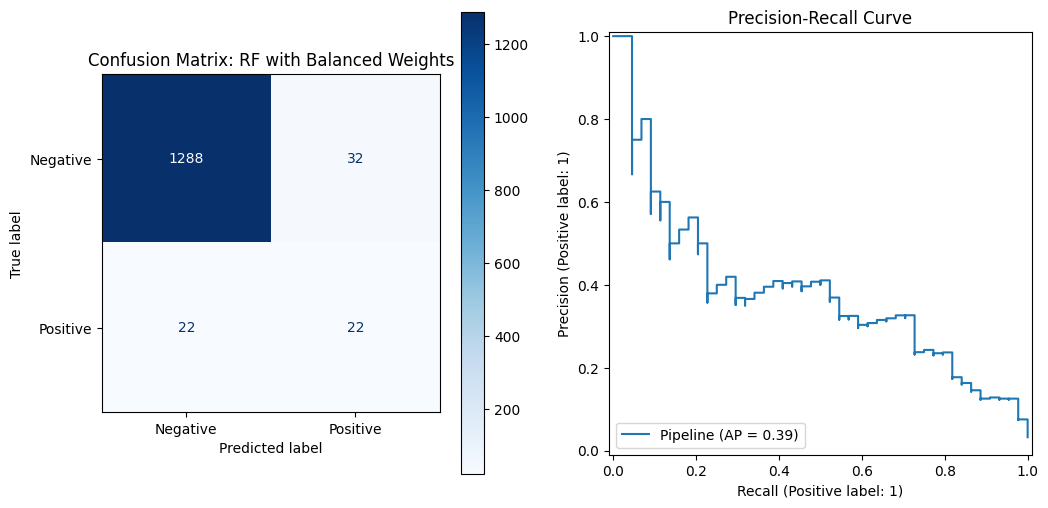

In [ ]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

y_probs = best_model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_probs)

print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(ncols = 2, figsize= (12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues, ax=ax[0])
ax[0].set_title("Confusion Matrix: RF with Balanced Weights")

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax[1])
ax[1].set_title("Precision-Recall Curve")
plt.show()
